# Workshop: Training a GAN on MNIST

In this workshop, you will build and train a **Generative Adversarial Network (GAN)** to generate handwritten digits (MNIST dataset).

## What you will build
A simple GAN where:
- the **generator** maps random noise vectors to 28×28 images
- the **discriminator** predicts whether an image is real or fake

We'll use **MNIST** so training stays lightweight.


## How to use this notebook

Cells marked with **TODO** are for you to complete.

A fully solution notebook is provided separately.


In [1]:
# Core imports
import math
import random
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils

# Reproducibility
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## 1. Load and inspect the data

We will use MNIST and normalize images to the range **[-1, 1]** because the generator will end with a **Tanh** activation.


In [2]:
# The following code does:
# 1) Define a transform that converts images to tensors
# 2) Normalize them with mean=0.5 and std=0.5 so pixel values end up in [-1, 1]
# 3) Load the MNIST training set
# 4) Create a DataLoader with batch_size=128 and shuffle=True

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

len(train_dataset)

60000

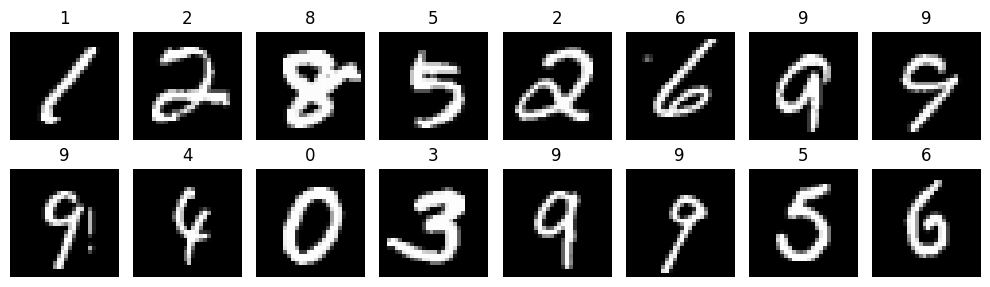

In [3]:
# Visualize a few real images
real_batch, real_labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 8, figsize=(10, 3))
for ax, img, label in zip(axes.flatten(), real_batch[:16], real_labels[:16]):
    ax.imshow(img.squeeze().cpu(), cmap="gray")
    ax.set_title(str(label.item()))
    ax.axis("off")
plt.tight_layout()
plt.show()

## 2. Define the Generator and Discriminator

We will keep both models simple and fully connected.

### Generator
- input: latent vector `z` of size `latent_dim`
- output: flattened 784-dimensional image, reshaped to `(1, 28, 28)`

### Discriminator
- input: flattened image
- output: probability that the image is real


In [ ]:
latent_dim = 100
image_dim = 28 * 28

In [ ]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100, image_dim=784):
        super().__init__()
        # TODO:
        # Build a small MLP generator, e.g.
        # latent_dim -> 128 -> 256 -> 512 -> image_dim
        # Use ReLU activations between hidden layers
        # Use Tanh on the output
        self.model = ...

    def forward(self, z):
        x = self.model(z)
        return x.view(-1, 1, 28, 28)


class Discriminator(nn.Module):
    def __init__(self, image_dim=784):
        super().__init__()
        # TODO:
        # Build a small MLP discriminator, e.g.
        # image_dim -> 512 -> 256 -> 1
        # Use LeakyReLU(0.2) between hidden layers
        # Use Sigmoid on the output
        self.model = ...

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.model(x)

In [ ]:
# Instantiate models
G = Generator(latent_dim=latent_dim, image_dim=image_dim).to(device)
D = Discriminator(image_dim=image_dim).to(device)

print(G)
print()
print(D)

## 3. Loss function and optimizers

For this workshop, we use the original GAN setup with:
- **binary cross-entropy loss**
- **Adam** optimizers

Typical GAN hyperparameters often use:
- learning rate = `2e-4`
- betas = `(0.5, 0.999)`


In [ ]:
# TODO:
# 1) Define BCE loss
# 2) Create optimizers for G and D using Adam
# 3) Use lr=2e-4 and betas=(0.5, 0.999)

criterion = nn.BCELoss()

g_optimizer = ...
d_optimizer = ...

## 4. Helper function to visualize generated samples

In [4]:
@torch.no_grad()
def show_generated_samples(generator, latent_dim=100, n=16):
    generator.eval()
    z = torch.randn(n, latent_dim, device=device)
    fake_images = generator(z).cpu()

    # Undo normalization from [-1, 1] to [0, 1] for display
    fake_images = (fake_images + 1) / 2

    grid = utils.make_grid(fake_images, nrow=4)
    plt.figure(figsize=(5, 5))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    plt.axis("off")
    plt.show()
    generator.train()

## 5. One GAN training step

In each iteration:
1. Train the discriminator on **real** images
2. Train the discriminator on **fake** images from the generator
3. Train the generator to fool the discriminator

### Label convention
- real labels = 1
- fake labels = 0


In [ ]:
def train_discriminator_step(real_images):
    batch_size = real_images.size(0)
    real_images = real_images.to(device)

    # TODO:
    # 1) Sample noise z (use torch.randn)
    # 2) Generate fake images with G
    # 3) Create real and fake label tensors
    # 4) Compute discriminator predictions on real and fake images
    # 5) Compute BCE losses for real and fake batches
    # 6) Sum them, backprop, optimizer step
    # 7) Return total discriminator loss as a Python float

    d_optimizer.zero_grad()

    z = ...
    fake_images = ...

    real_targets = ...
    fake_targets = ...

    real_preds = ...
    fake_preds = ...

    real_loss = ...
    fake_loss = ...
    d_loss = ...

    d_loss.backward()
    d_optimizer.step()

    return d_loss.item()

In [ ]:
def train_generator_step(batch_size):
    # TODO:
    # 1) Sample noise z
    # 2) Generate fake images
    # 3) Create target labels of 1s because G wants D(fake) to look real
    # 4) Compute discriminator predictions on fake images
    # 5) Compute generator loss, backprop, optimizer step
    # 6) Return generator loss as a Python float

    g_optimizer.zero_grad()

    z = ...
    fake_images = ...

    targets = ...
    preds = ...

    g_loss = ...

    g_loss.backward()
    g_optimizer.step()

    return g_loss.item()

## 6. Full training loop

Train for a few epochs and inspect:
- discriminator loss
- generator loss
- generated samples over time

### Questions to think about
- What happens if the discriminator becomes too strong?
- What does mode collapse look like?
- Do low losses always mean good generated images?


In [ ]:
num_epochs = 10

g_losses = []
d_losses = []

for epoch in range(num_epochs):
    g_running = 0.0
    d_running = 0.0

    for real_images, _ in train_loader:
        # The following code does:
        # Run one discriminator step and one generator step
        # Accumulate the losses into g_running and d_running
        d_loss = train_discriminator_step(real_images)
        g_loss = train_generator_step(real_images.size(0))

        d_running += d_loss
        g_running += g_loss

    avg_d = d_running / len(train_loader)
    avg_g = g_running / len(train_loader)

    d_losses.append(avg_d)
    g_losses.append(avg_g)

    print(f"Epoch {epoch+1:02d}/{num_epochs} | D loss: {avg_d:.4f} | G loss: {avg_g:.4f}")

    if (epoch + 1) % 2 == 0:
        show_generated_samples(G, latent_dim=latent_dim, n=16)

## 7. Plot the learning curves

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(d_losses, label="Discriminator loss")
plt.plot(g_losses, label="Generator loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN training losses")
plt.legend()
plt.show()